In [1]:
import math

import seaborn as sns
import torch
from matplotlib import pyplot as plt

sns.set()

from hyperbolic.poincare import distance, distance_center, geodesic, moebius

In [2]:
# check that poincare distance grows exponentially
lin = torch.linspace(0, 0.705, 1000)
zs = torch.complex(lin, lin).reshape(1000, 1)
centers = torch.complex(torch.zeros(1000), torch.zeros(1000)).reshape(1000, 1)

distances = torch.vmap(distance, in_dims=(0, 0, None))(centers, zs, "disk")

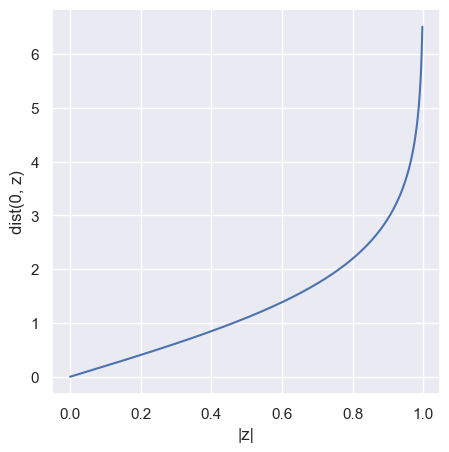

In [3]:
# plot distances from the center
plt.figure(figsize=(5, 5))
plt.plot(zs.abs(), distances)
plt.xlabel("|z|")
plt.ylabel("dist(0, z)")
plt.savefig("images/dist_exponential.png", dpi=500)
plt.show()

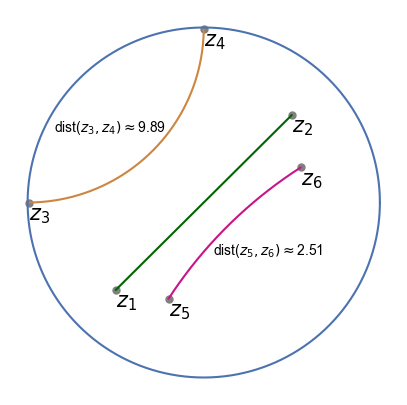

In [4]:
# create the sphere S^1 as the boudary of the poincare disk
x_sphere = torch.cos(torch.linspace(0, 2 * math.pi, 1000))
y_sphere = torch.sin(torch.linspace(0, 2 * math.pi, 1000))
sphere = torch.complex(x_sphere, y_sphere)

# create points in the disk
z1 = torch.complex(torch.tensor([-0.5]), torch.tensor([-0.5]))
z2 = torch.complex(torch.tensor([0.5]), torch.tensor([0.5]))
z3 = torch.complex(torch.tensor([-0.99]), torch.tensor([0.0]))
z4 = torch.complex(torch.tensor([0.0]), torch.tensor([0.99]))
z5 = torch.complex(torch.tensor([-0.2]), torch.tensor([-0.55]))
z6 = torch.complex(torch.tensor([0.55]), torch.tensor([0.2]))
points = {
    r"$z_1$": z1,
    r"$z_2$": z2,
    r"$z_3$": z3,
    r"$z_4$": z4,
    r"$z_5$": z5,
    r"$z_6$": z6,
}

# values the geodesic curve gets computed for
ts = torch.linspace(0, 1, 1000).reshape(1000, 1)

# compute geodesics
geod_z1_z2 = torch.vmap(geodesic, in_dims=(None, None, 0, None))(z1, z2, ts, "disk")
geod_z3_z4 = torch.vmap(geodesic, in_dims=(None, None, 0, None))(z3, z4, ts, "disk")
geod_z5_z6 = torch.vmap(geodesic, in_dims=(None, None, 0, None))(z5, z6, ts, "disk")

# compute distances
dist_z3_z4 = distance(z3, z4, "disk")
dist_z5_z6 = distance(z5, z6, "disk")

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(geod_z1_z2.real, geod_z1_z2.imag, color="darkgreen")
ax.plot(geod_z3_z4.real, geod_z3_z4.imag, color="peru")
ax.plot(geod_z5_z6.real, geod_z5_z6.imag, color="mediumvioletred")
ax.plot(sphere.real, sphere.imag)
ax.scatter(
    [z1.real, z2.real, z3.real, z4.real, z5.real, z6.real],
    [z1.imag, z2.imag, z3.imag, z4.imag, z5.imag, z6.imag],
    c="grey",
    s=25,
)
plt.axis("off")
for name, val in points.items():
    ax.annotate(name, (val.real, val.imag - 0.1), fontsize=15, c="black")

ax.annotate(
    r"dist($z_3, z_4) \approx $%.2f " % dist_z3_z4.item(),
    (-0.85, 0.4),
    fontsize=10,
    color="black",
)
ax.annotate(
    r"dist($z_5, z_6) \approx $%.2f " % dist_z5_z6.item(),
    (0.05, -0.3),
    fontsize=10,
    color="black",
)
plt.savefig("images/geodesics_disk.png", dpi=500)
plt.show()

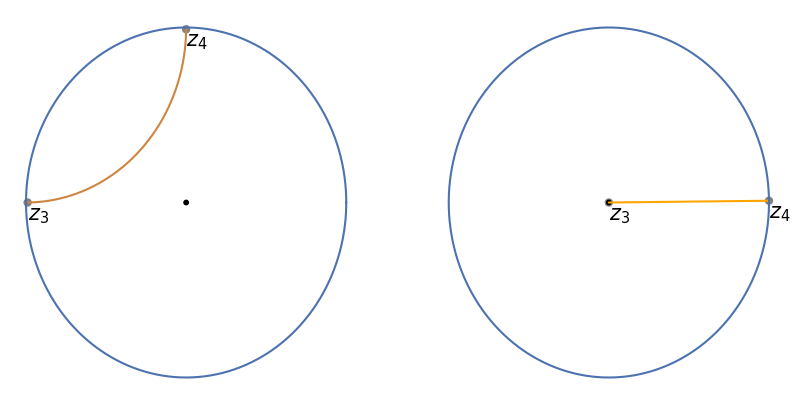

tensor(2.5119)
tensor([2.5119])
tensor([0.+0.j])
tensor([0.9998+0.0100j])


In [23]:
moeb_geod_z3_z4 = torch.vmap(moebius, in_dims=(0, None, None))(geod_z3_z4, z3, "disk")
moeb_z3, moeb_z4 = moebius(z3, z3, "disk"), moebius(z4, z3, "disk")
moeb_geod_z3_z4 = torch.exp(torch.view_as_complex(torch.tensor([0.0, 1.0])) * 2*math.pi) * moeb_geod_z3_z4

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
points = {
    r"$z_3$": z3,
    r"$z_4$": z4
}

moeb_points = {
    r"$z_3$": moeb_z3,
    r"$z_4$": moeb_z4
}

ax1.plot(geod_z3_z4.real, geod_z3_z4.imag, color="peru")
ax1.plot(sphere.real, sphere.imag)
ax1.scatter(
    [z3.real, z4.real, torch.zeros(1)],
    [z3.imag, z4.imag, torch.zeros(1)],
    c=["grey", "grey", "black"],
    s=[25, 25, 10]
)
ax1.axis("off")
for name, val in points.items():
    ax1.annotate(name, (val.real, val.imag - 0.1), fontsize=15, c="black")

ax2.plot(moeb_geod_z3_z4.real, moeb_geod_z3_z4.imag, color="orange")
ax2.plot(sphere.real, sphere.imag)
ax2.scatter(
    [moeb_z3.real, moeb_z4.real, torch.zeros(1)],
    [moeb_z3.imag, moeb_z4.imag, torch.zeros(1)],
    c=["grey", "grey", "black"],
    s=[25, 25, 10]
)
ax2.axis("off")
for name, val in moeb_points.items():
    ax2.annotate(name, (val.real, val.imag - 0.1), fontsize=15, c="black")

plt.show()

print(distance(z5, z6, "disk"))
print(distance_center(moeb_z6, "disk"))
print(moeb_z3)
print(moeb_z4)